# Red Neuronal
### Limpieza de datos
1. Leemos el dataset con pandas
2. Revision del dataframe
3. Revisar los tipos de datos
4. Eliminar valores duplicado y valores nulos
5. Reemplazar datos faltantes.
6. Limpiar todas las columnas numericas y objeto
7. Revisar datos categoricos
8. Detectar valores fuera de rango
9. Deteccion de Outliers con IQR (metodos estadisticos)
10. Comprobar el balanceo de datos
Si hay datos desbalanceados la neurona no aprende adecuadamente.
11. Estandarizar los datos
edad 3 - 103 -> 3+103/2 = 106/2 = 53 X
34-80
12. Division de datos de entrenamiento y prueba
13. Creamos el modelo

In [ ]:
import pandas as pd
URL = "https://raw.githubusercontent.com/ShuklaPrashant21/Used-Car-Price-Prediction/refs/heads/master/car%20data.csv"

ruta = r"URL"
df = pd.read_csv(URL)
df.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint,fecha
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00,1959-01-01
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74,1959-04-01
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09,1959-07-01
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06,1959-10-01
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19,1960-01-01


In [ ]:
#importamos las librerias
import numpy as np
import matplotlib.pyplot as plt # crear graficas
#sklearn sirve para realizar el prepocesamiento
from sklearn.model_selection import train_test_split #division de datos de entrenamiento y prueba
#Estandarizacion de datos
from sklearn.preprocessing import StandardScaler, LabelEncoder
#OneHotEncoder
#Matriz de confusion
from sklearn.metrics import confusion_matrix,classification_report
#Sirve para clasificacion
"""
TP = Verdaderos Positivos
TN = Verdaderos Negativos
FP = Falsos Positivos
FN = Falsos Negativos
Reporte de clasificacion Accuracy, Sensibility, AUC
"""

'\nTP = Verdaderos Positivos\nTN = Verdaderos Negativos\nFP = Falsos Positivos\nFN = Falsos Negativos\nReporte de clasificacion Accuracy, Sensibility, AUC\n'

In [ ]:
#cargar las librerias para el modelo de deep learning
from tensorflow.keras.models import Sequential #Guardamos cada capa del modelo
from tensorflow.keras.layers import Dense #Creamos las neuronas
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2

In [355]:
#Obtener el tamaño completo del dataset
df.shape

(203, 15)

In [356]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      203 non-null    float64
 1   quarter   203 non-null    float64
 2   realgdp   203 non-null    float64
 3   realcons  203 non-null    float64
 4   realinv   203 non-null    float64
 5   realgovt  203 non-null    float64
 6   realdpi   203 non-null    float64
 7   cpi       203 non-null    float64
 8   m1        203 non-null    float64
 9   tbilrate  203 non-null    float64
 10  unemp     203 non-null    float64
 11  pop       203 non-null    float64
 12  infl      203 non-null    float64
 13  realint   203 non-null    float64
 14  fecha     203 non-null    str    
dtypes: float64(14), str(1)
memory usage: 23.9 KB


In [ ]:
#Exploramos dataset
df.describe()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
count,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000,203.000000
mean,1983.876847,2.492611,7221.171901,4825.293103,1012.863862,663.328640,5310.540887,105.075788,667.927586,5.311773,5.884729,239.724153,3.961330,1.336502
std,14.686817,1.118563,3214.956044,2313.346192,585.102267,140.863655,2423.515977,61.278878,455.346381,2.803071,1.458574,37.390450,3.253216,2.668799
min,1959.000000,1.000000,2710.349000,1707.400000,259.764000,460.400000,1886.900000,28.980000,139.600000,0.120000,3.400000,177.146000,-8.790000,-6.790000
25%,1971.000000,1.500000,4440.103500,2874.100000,519.147500,527.959500,3276.950000,41.050000,228.650000,3.515000,4.900000,208.631000,2.270000,-0.085000
50%,1984.000000,2.000000,6559.594000,4299.900000,896.210000,662.412000,4959.400000,104.100000,540.900000,5.010000,5.700000,236.348000,3.240000,1.340000
75%,1996.500000,3.000000,9629.346500,6398.150000,1436.681500,773.049000,6977.850000,159.650000,1102.100000,6.665000,6.800000,271.721500,4.975000,2.630000
max,2009.000000,4.000000,13415.266000,9363.600000,2264.721000,1044.088000,10077.500000,218.610000,1673.900000,15.330000,10.700000,308.013000,14.620000,10.950000


In [ ]:
print(df['quarter'].unique()) #Ver si las etiquetas son unicas

[1. 2. 3. 4.]


In [ ]:
print(df['quarter'].value_counts())

quarter
1.0    51
2.0    51
3.0    51
4.0    50
Name: count, dtype: int64


In [ ]:
#Limpieza de datos
#Buscar valores faltantes
print(df.isnull().sum())

year        0
quarter     0
realgdp     0
realcons    0
realinv     0
realgovt    0
realdpi     0
cpi         0
m1          0
tbilrate    0
unemp       0
pop         0
infl        0
realint     0
fecha       0
dtype: int64


In [361]:
#Buscar duplicados
print(df.duplicated().sum()) #contamos cantidad de duplicados
df = df.drop_duplicates() #eliminamos duplicados
print(df.duplicated().sum())

0
0


In [362]:
#Usamos la media para los valores faltantes
columnas_num = df.select_dtypes(include=np.number).columns
df[columnas_num] = df[columnas_num].fillna(df[columnas_num].mean())

In [363]:
print(df.isnull().sum())
print(df.duplicated().sum())

year        0
quarter     0
realgdp     0
realcons    0
realinv     0
realgovt    0
realdpi     0
cpi         0
m1          0
tbilrate    0
unemp       0
pop         0
infl        0
realint     0
fecha       0
dtype: int64
0


In [364]:
X = df[["realcons","realinv","realdpi","realint","cpi","infl"]]
y = df["realgdp"]
print(X.head())
print(y.head())

   realcons  realinv  realdpi  realint    cpi  infl
0    1707.4  286.898   1886.9     0.00  28.98  0.00
1    1733.7  310.859   1919.7     0.74  29.15  2.34
2    1751.8  289.226   1916.4     1.09  29.35  2.74
3    1753.7  299.356   1931.3     4.06  29.37  0.27
4    1770.5  331.722   1955.5     1.19  29.54  2.31
0    2710.349
1    2778.801
2    2775.488
3    2785.204
4    2847.699
Name: realgdp, dtype: float64


In [365]:
#conertir ese objeto a un dato numerico
#convertir ese dato objeto a un dato dummy
#codificar las clases
#encoder = LabelEncoder()
#y = encoder.fit_transform(y)
#print(y)

In [366]:
#print(encoder.classes_)

In [367]:
#Dividir datos de entrenamiento y datos de prueba
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [368]:
print(X_train.head())
print(X_test.head())
print(y_train)
print(y_test)

     realcons   realinv  realdpi  realint      cpi   infl
198    9267.7  1990.693   9838.3     4.33  216.889  -3.16
93     3847.7   691.900   4500.8     1.58   97.500  10.39
38     2611.5   476.053   2899.3     0.65   35.300   4.56
24     2188.8   429.145   2447.4     2.65   31.380   1.28
96     3986.6   645.110   4572.2     4.56   98.800   3.66
     realcons   realinv  realdpi  realint     cpi  infl
15     1945.1   325.650   2154.6     2.08   30.44  0.79
9      1814.3   286.246   2014.4     0.81   29.92  1.47
115    4922.2  1021.980   5493.1     2.29  116.00  3.46
78     3711.4   801.452   4177.1    -2.01   67.10  9.65
66     3241.4   516.402   3698.6    -0.34   54.90  6.61
198    13324.600
93      5889.074
38      4160.267
24      3516.251
96      5944.020
         ...    
106     6903.523
14      3093.047
92      5857.333
179    12042.817
102     6623.343
Name: realgdp, Length: 162, dtype: float64
15      3100.563
9       2872.005
115     7458.022
78      5740.300
66      4913.328
4

In [369]:
#escalado de datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) 
print(X_train[1])

[-0.40251978 -0.53616873 -0.31390079  0.08216061 -0.10964926  2.05688453]


In [370]:
#Modificacion Axel
import numpy as np
print(np.unique(y_train))
print(len(np.unique(y_train)))

[ 2710.349  2775.488  2778.801  2785.204  2802.616  2819.264  2834.39
  2839.022  2847.699  2918.419  2977.83   3031.241  3064.709  3093.047
  3180.447  3264.967  3338.246  3376.587  3422.469  3431.957  3516.251
  3563.96   3636.285  3724.014  3815.423  3828.124  3884.52   3918.74
  3919.556  3950.826  3980.97   4063.013  4131.998  4160.267  4178.293
  4244.1    4256.46   4256.573  4256.637  4263.261  4283.378  4302.259
  4374.016  4398.829  4433.943  4446.264  4525.769  4633.101  4677.503
  4795.295  4854.34   4873.52   4906.252  4909.617  4922.188  4932.571
  4953.05   5154.072  5191.499  5251.762  5356.131  5450.793  5451.921
  5684.569  5787.373  5825.949  5831.418  5857.333  5866.37   5883.46
  5889.074  5889.495  5944.02   5955.062  5957.795  6005.717  6030.184
  6197.468  6325.574  6559.594  6623.343  6677.264  6740.275  6797.344
  6903.523  6955.918  7022.757  7050.969  7118.95   7153.359  7193.019
  7269.51   7332.558  7496.6    7592.881  7632.082  7733.991  7806.603
  7865.01

In [371]:
#Creamos el modelo
#Qué hace: en cada paso de entrenamiento, "apaga" aleatoriamente un porcentaje de neuronas (las pone en 0), y en cada batch son neuronas distintas.
modelo = Sequential([
    Dense(8, activation="relu", input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.01)),
    Dense(8, activation="relu", kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(1, activation="linear")
])
#Mostramos la arquitectura
modelo.summary()

#20 = 100
#x= 30 =6

c:\Users\pumas\OneDrive\Documents\.venv13\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

In [372]:
#Compilamos la red
#perdidas categoricas se ocupan cuando tenemos multiples clases
modelo.compile(optimizer = "adam",loss = "mse",metrics=["mae"])

In [373]:
print(X_train.shape)  # verifica cuántas columnas tiene realmente
modelo.summary() 

(162, 6)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

In [374]:
#Entrenamos la red
#historial = modelo.fit(X_train,y_train,epochs=1000,batch_size=16,validation_split = 0.2, verbose = 1)

from tensorflow.keras.callbacks import EarlyStopping

#Qué hace: monitorea una métrica (normalmente val_loss) después de cada época, y si esa métrica deja 
# de mejorar durante un número de épocas seguidas, detiene el entrenamiento automáticamente.

early_stop = EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True)

historial = modelo.fit(
    X_train, y_train,
    epochs=1000,
    batch_size=16,
    validation_split=0.2
)


Epoch 1/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 60145744.0000 - mae: 7059.5566 - val_loss: 68453296.0000 - val_mae: 7591.0547
Epoch 2/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 60144828.0000 - mae: 7059.4980 - val_loss: 68451568.0000 - val_mae: 7590.9404
Epoch 3/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 60144552.0000 - mae: 7059.4941 - val_loss: 68449832.0000 - val_mae: 7590.8296
Epoch 4/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 60142176.0000 - mae: 7059.3545 - val_loss: 68448152.0000 - val_mae: 7590.7231
Epoch 5/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 60139088.0000 - mae: 7059.1284 - val_loss: 68446448.0000 - val_mae: 7590.6157
Epoch 6/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 60139744.0000 - mae: 7059.1450 - val_loss: 68444688.0000 - val_mae: 7590.5039
Epoch 7/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 60137744.0000 - mae: 7058.9980 - val_loss: 68442904.0000 - val_mae: 7590.3926
Epoch 8/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 

<function matplotlib.pyplot.show(close=None, block=None)>

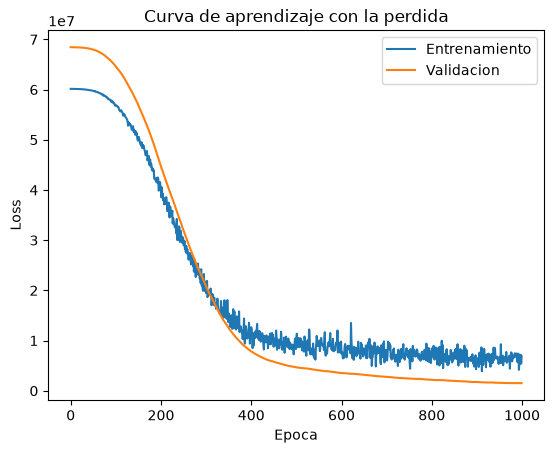

In [375]:
#graficar el aprendizaje de la red
plt.plot(historial.history["loss"],label = "Entrenamiento")
plt.plot(historial.history["val_loss"],label="Validacion")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.title("Curva de aprendizaje con la perdida")
plt.legend()
plt.show

In [376]:
plt.plot(historial.history["accuracy"],label = "Entrenamiento")
plt.plot(historial.history["val_accuracy"],label="Validacion")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.title("Curva de aprendizaje con accuracy")
plt.legend()
plt.show

KeyError: 'accuracy'

In [377]:
loss = modelo.evaluate(X_test,y_test)
print("Loss",loss)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1231116.5000 - mae: 967.1401
Loss [1231116.5, 967.1400756835938]


In [384]:
probabilidades = modelo.predict(X_test)
print(y_test)
print(probabilidades)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
15      3100.563
9       2872.005
115     7458.022
78      5740.300
66      4913.328
45      4264.289
143     9003.180
177    11738.706
200    12925.410
180    12127.623
69      5128.947
162    10819.914
166    11267.867
187    12748.699
56      4876.166
190    12965.916
18      3240.332
79      5816.222
55      4754.546
145     9044.668
176    11645.819
97      6077.619
95      5871.001
30      3853.301
126     8059.476
16      3141.087
173    11538.770
86      5776.617
163    11014.254
124     8027.693
65      4831.942
68      5090.663
127     7988.864
67      4977.511
76      5469.405
100     6448.264
139     8643.769
137     8486.435
165    11258.454
84      5908.467
82      5873.335
Name: realgdp, dtype: float64
[[ 2937.581 ]
 [ 2995.8914]
 [ 5659.858 ]
 [ 4459.3096]
 [ 4121.1787]
 [ 3972.9333]
 [ 7789.645 ]
 [10917.527 ]
 [12343.011 ]
 [11163.494 ]
 [ 3696.2468]
 [ 9523.391 ]
 [10791.984 ]
 [13447.059 ]
 [ 4336.9004]
 [14542.994 ]
 [ 2995.408

In [ ]:
#Encontramos la neurona que produjo el mayor valor
#predicciones = np.argmax(probabilidades, axis=1)
#print(predicciones)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0]


In [386]:
#Comparamos la salida real con la prediccion
resultados = pd.DataFrame({
    "Real":y_test,
    "Prediccion":predicciones
})
print(resultados)

          Real  Prediccion
15    3100.563           0
9     2872.005           0
115   7458.022           0
78    5740.300           0
66    4913.328           0
45    4264.289           0
143   9003.180           0
177  11738.706           0
200  12925.410           0
180  12127.623           0
69    5128.947           0
162  10819.914           0
166  11267.867           0
187  12748.699           0
56    4876.166           0
190  12965.916           0
18    3240.332           0
79    5816.222           0
55    4754.546           0
145   9044.668           0
176  11645.819           0
97    6077.619           0
95    5871.001           0
30    3853.301           0
126   8059.476           0
16    3141.087           0
173  11538.770           0
86    5776.617           0
163  11014.254           0
124   8027.693           0
65    4831.942           0
68    5090.663           0
127   7988.864           0
67    4977.511           0
76    5469.405           0
100   6448.264           0
1

In [ ]:
#Matriz de confusion
matriz = confusion_matrix(y_test,predicciones)
print(matriz)
#            ['Setosa' 'Versicolor' 'Virginica'] #salidas reales
#[Setosa]       10          0             0
#[Versicolor]    1          5             0
#[Virginica]     0          0             10
#salida predicha

[[0 0 2 8]
 [0 0 1 9]
 [0 0 2 9]
 [0 0 3 7]]


In [ ]:
#Reporte de clasificacion
print(classification_report(y_test,predicciones,target_names=encoder.classes_.astype(str)))
#precision cuantos de los datos (ej setosa, versicolor o virginica) acerte?
#Recall de setosa, versicolor o virginica, cuantos encontre?
#F1-score que tan equilibrado esta precision y recall?

              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00        10
         2.0       0.00      0.00      0.00        10
         3.0       0.25      0.18      0.21        11
         4.0       0.21      0.70      0.33        10

    accuracy                           0.22        41
   macro avg       0.12      0.22      0.13        41
weighted avg       0.12      0.22      0.14        41



c:\Users\pumas\OneDrive\Documents\.venv13\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pumas\OneDrive\Documents\.venv13\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pumas\OneDrive\Documents\.venv13\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

Con su dataset deberan realizar lo siguiente:
1. Preprocesamiento
2. Limpieza de datos
3. Creacion de modelo
4. Clasificacion
5. Mostrar Matriz de confusion
6. Mostrar reporte de clasificacion
si su dataset no tiene etiquetas deberan cambiarlo por otro.